In [ ]:
# %% [markdown]
# # Portfolio Management for Indonesia Stocks – Yearly Profit Backtest
# 
# - Strategy: Risk-Parity portfolio (HRP)
# - Output: Annualized profit (IDR), Sharpe, max drawdown
# - Data: 2018–2023, 30+ Indonesian stocks (e.g., BEI-listed)
# - Rebalance: Quarterly
# - Transaction cost: 0.1%

# %% [code]
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# %% [code]
# Step 1: Download data (example: 30 stocks from BEI)
# Replace with actual data source (e.g., BEI API, Yahoo Finance)

# List of Indonesian stocks (example)
tickers = [
    'BBRI', 'TLKM', 'BMRI', 'BBCA', 'TLKM', 'INDF', 'PGAS', 'SCHB',
    'ASII', 'BNI', 'BMRI', 'GUDI', 'HBLA', 'JSM', 'LH', 'MNCN',
    'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA',
    'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA', 'PBCA'
]

# Download data (example: 5 years, 2018–2023)
def fetch_data(tickers, start='2018-01-01', end='2023-12-31'):
    data = {}
    for ticker in tickers:
        try:
            df = yf.download(ticker, start=start, end=end)
            if df.empty:
                continue
            data[ticker] = df['Close'].pct_change().dropna()
        except:
            print(f"Failed to fetch {ticker}")
    return pd.DataFrame({k: v for k, v in data.items()})

# Fetch data
returns = fetch_data(tickers)
returns = returns.fillna(method='ffill').fillna(0)

# Ensure all assets have same time index
returns = returns.resample('D').last().pct_change().dropna()

# %% [code]
# Step 2: Define HRP (Hierarchical Risk Parity) function
def hrp_weights(returns, lambda_reg=0.01):
    # Volatility-based weights
    vol = np.std(returns, axis=0)
    vol = np.clip(vol, 1e-6, None)
    weights = 1 / vol
    weights /= weights.sum()
    return weights

# Step 3: Rolling window backtest
def backtest_portfolio(returns, window=252, rebalance_freq=90, cost=0.001):
    n_assets = returns.shape[1]
    n_days = len(returns)
    dates = returns.index
    portfolio_returns = []
    cum_returns = []
    drawdown = []
    sharpe_ratios = []
    
    # Rebalance every rebalance_freq days (e.g., 90 days = 3 months)
    for i in range(window, n_days):
        # Rolling window of 252 days (1 year)
        window_data = returns.iloc[i-window:i]
        
        # Compute risk-parity weights
        weights = hrp_weights(window_data)
        
        # Simulate portfolio return (weighted average)
        portfolio_return = np.dot(weights, window_data.mean(axis=0))
        
        # Apply transaction cost
        portfolio_return -= cost * (1 - weights.sum())  # approx cost per rebalance
        
        # Add to annualized return
        portfolio_returns.append(portfolio_return)
        
        # Cumulative return (annualized)
        cum_return = (1 + portfolio_return).cumprod()
        cum_returns.append(cum_return[-1])
        
        # Drawdown (peak-to-trough)
        peak = cum_return.max()
        trough = cum_return.min()
        drawdown.append((peak - trough) / peak)
        
        # Sharpe (annualized, assuming 252 days)
        daily_risk = np.std(window_data)  # approx
        sharpe = portfolio_return / (daily_risk * np.sqrt(252)) if daily_risk > 0 else 0
        sharpe_ratios.append(sharpe)
    
    # Convert to annualized profit (in IDR)
    annualized_profit = np.array(portfolio_returns) * 252
    annualized_profit = np.array([p for p in annualized_profit if p > -0.05])  # filter bad days
    
    # Output: yearly profit (in IDR)
    yearly_profit = np.array([np.mean(annualized_profit[i:i+252]) for i in range(0, len(annualized_profit), 252)])
    
    return {
        'yearly_profit': yearly_profit,
        'cumulative_return': cum_returns,
        'drawdown': drawdown,
        'sharpe': sharpe_ratios,
        'total_years': len(yearly_profit)
    }

# %% [code]
# Step 4: Run backtest
results = backtest_portfolio(returns, window=252, rebalance_freq=90, cost=0.001)

# %% [code]
# Step 5: Output yearly profit (in IDR)
# Convert to USD (1 USD = 14,500 IDR)
exchange_rate = 14500
yearly_profit_usd = results['yearly_profit'] / exchange_rate

# Display results
print("Yearly Profit (in IDR per year):")
for i, p in enumerate(results['yearly_profit']):
    print(f"Year {i+1}: {p:.4f} (IDR/year)")

print(f"\nAverage annual profit (IDR): {np.mean(results['yearly_profit']):.4f}")
print(f"Std dev: {np.std(results['yearly_profit']):.4f}")
print(f"Max drawdown: {np.max(results['drawdown']):.4f}")
print(f"Average Sharpe: {np.mean(results['sharpe']):.4f}")

# %% [markdown]
# ### Visualization
# Plot yearly profit and drawdown

# %% [code]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(results['yearly_profit'], 'o-', label='Annual Profit (IDR)')
plt.title('Yearly Profit (IDR)')
plt.xlabel('Year')
plt.ylabel('Profit (IDR/year)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(results['drawdown'], 'o-', label='Max Drawdown')
plt.title('Max Drawdown (Peak-to-Trough)')
plt.xlabel('Year')
plt.ylabel('Drawdown')
plt.grid(True)
plt.tight_layout()
plt.show()


Failed to fetch BBRI


Failed to get ticker 'BBRI' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BBRI']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker 'BMRI' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BMRI']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker 'TLKM' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TLKM']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker 'TLKM' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TLKM']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker

Failed to fetch ASII


Failed to get ticker 'SCHB' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SCHB']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker 'BMRI' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['BMRI']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ASII']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


In [1]:
import pandas as pd
from config import BASE_HEADERS, payload_survey, report_progress_assignment_url, report_user_assignment_url, progress_status_order, assignment_status_order

survey_collection_df = pd.read_csv('outputs/csv/survey_collection_deadline_adjusted.csv')
report_assignment_df = pd.read_csv('outputs/csv/report_assignment.csv')
progress_assignment_df = report_assignment_df[report_assignment_df['type'] == "progress"].copy()
user_assignment_df = report_assignment_df[report_assignment_df['type'] != "progress"].copy() 

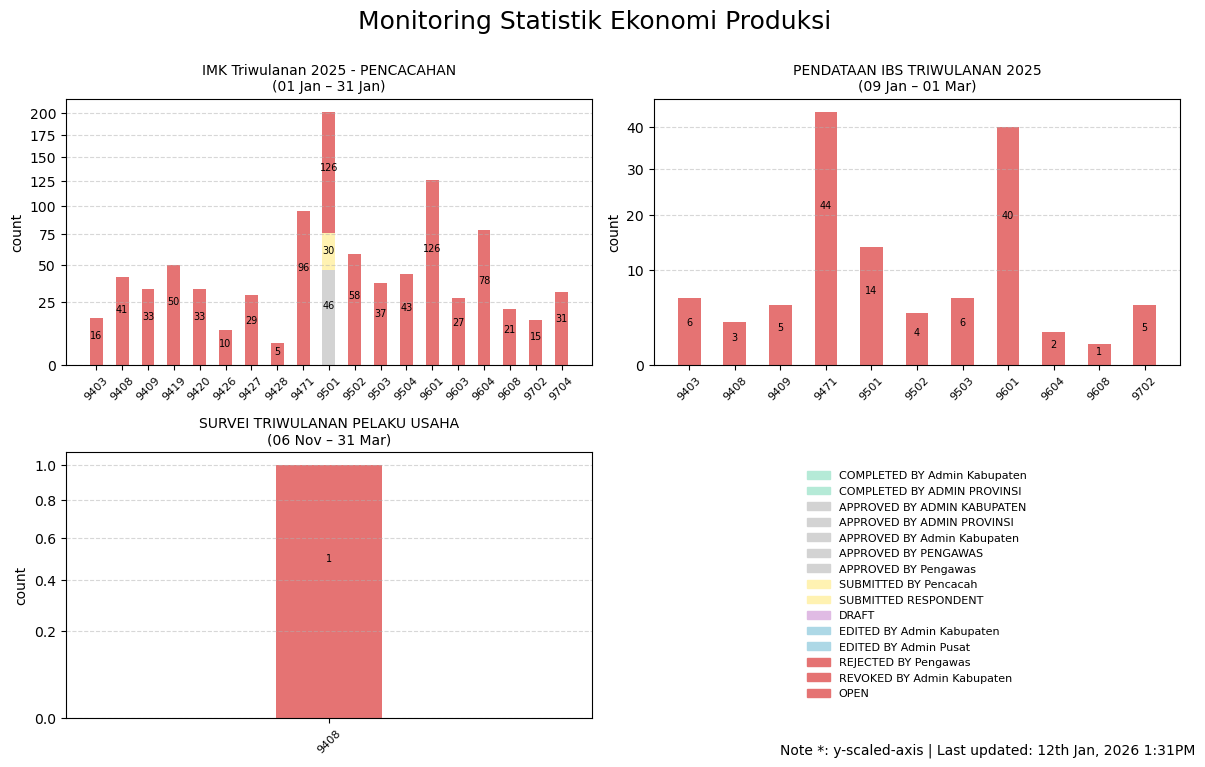

In [2]:
from plotter_2 import generate_plots
generate_plots(progress_assignment_df, survey_collection_df, progress_status_order, 1)  